In this notebook, let's do our initial data exploration. Some things I think we should include:
- Stats + Distributions
- Plots (bar charts + heatmaps)
- Correlation (Chi-squared)

In [2]:
import pandas as pd 
import matplotlib.pyplot as plt


# loading data and labeling columns

columns = ['target', 'cap-shape', 'cap-surface', 'cap-color', 'bruises',
           'odor', 'gill-attachment', 'gill-spacing', 'gill-size',
           'gill-color', 'stalk-shape', 'stalk-root', 'stalk-surface-above-ring',
           'stalk-surface-below-ring', 'stalk-color-above-ring',
           'stalk-color-below-ring', 'veil-type', 'veil-color',
           'ring-number', 'ring-type', 'spore-print-color',
           'population', 'habitat']

df = pd.read_csv('../data/agaricus-lepiota.data', header = None, names = columns)

df.head()

,target,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


target
e    4208
p    3916
Name: count, dtype: int64


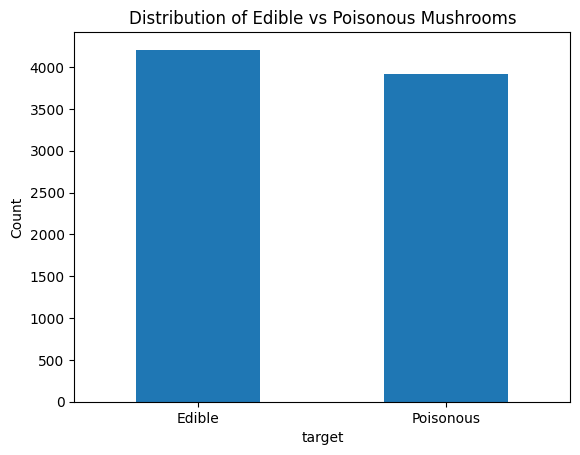

In [3]:
# target variable EDA

print(df['target'].value_counts())

df['target'].value_counts().plot(kind = 'bar')
plt.title('Distribution of Edible vs Poisonous Mushrooms')
plt.xticks(ticks=[0, 1], labels=['Edible', 'Poisonous'], rotation=0)
plt.ylabel('Count')
plt.savefig('../results/target_distribution.png')
plt.show()

In [4]:
# finding missing values
print(df.isnull().sum())

target                      0
cap-shape                   0
cap-surface                 0
cap-color                   0
bruises                     0
odor                        0
gill-attachment             0
gill-spacing                0
gill-size                   0
gill-color                  0
stalk-shape                 0
stalk-root                  0
stalk-surface-above-ring    0
stalk-surface-below-ring    0
stalk-color-above-ring      0
stalk-color-below-ring      0
veil-type                   0
veil-color                  0
ring-number                 0
ring-type                   0
spore-print-color           0
population                  0
habitat                     0
dtype: int64


In [5]:
# stalk-root missing vals
for col in df.columns:
    if '?' in df[col].values:
        count = (df[col] == '?').sum()
        print(f"{col}: {count} missing values")

stalk-root: 2480 missing values


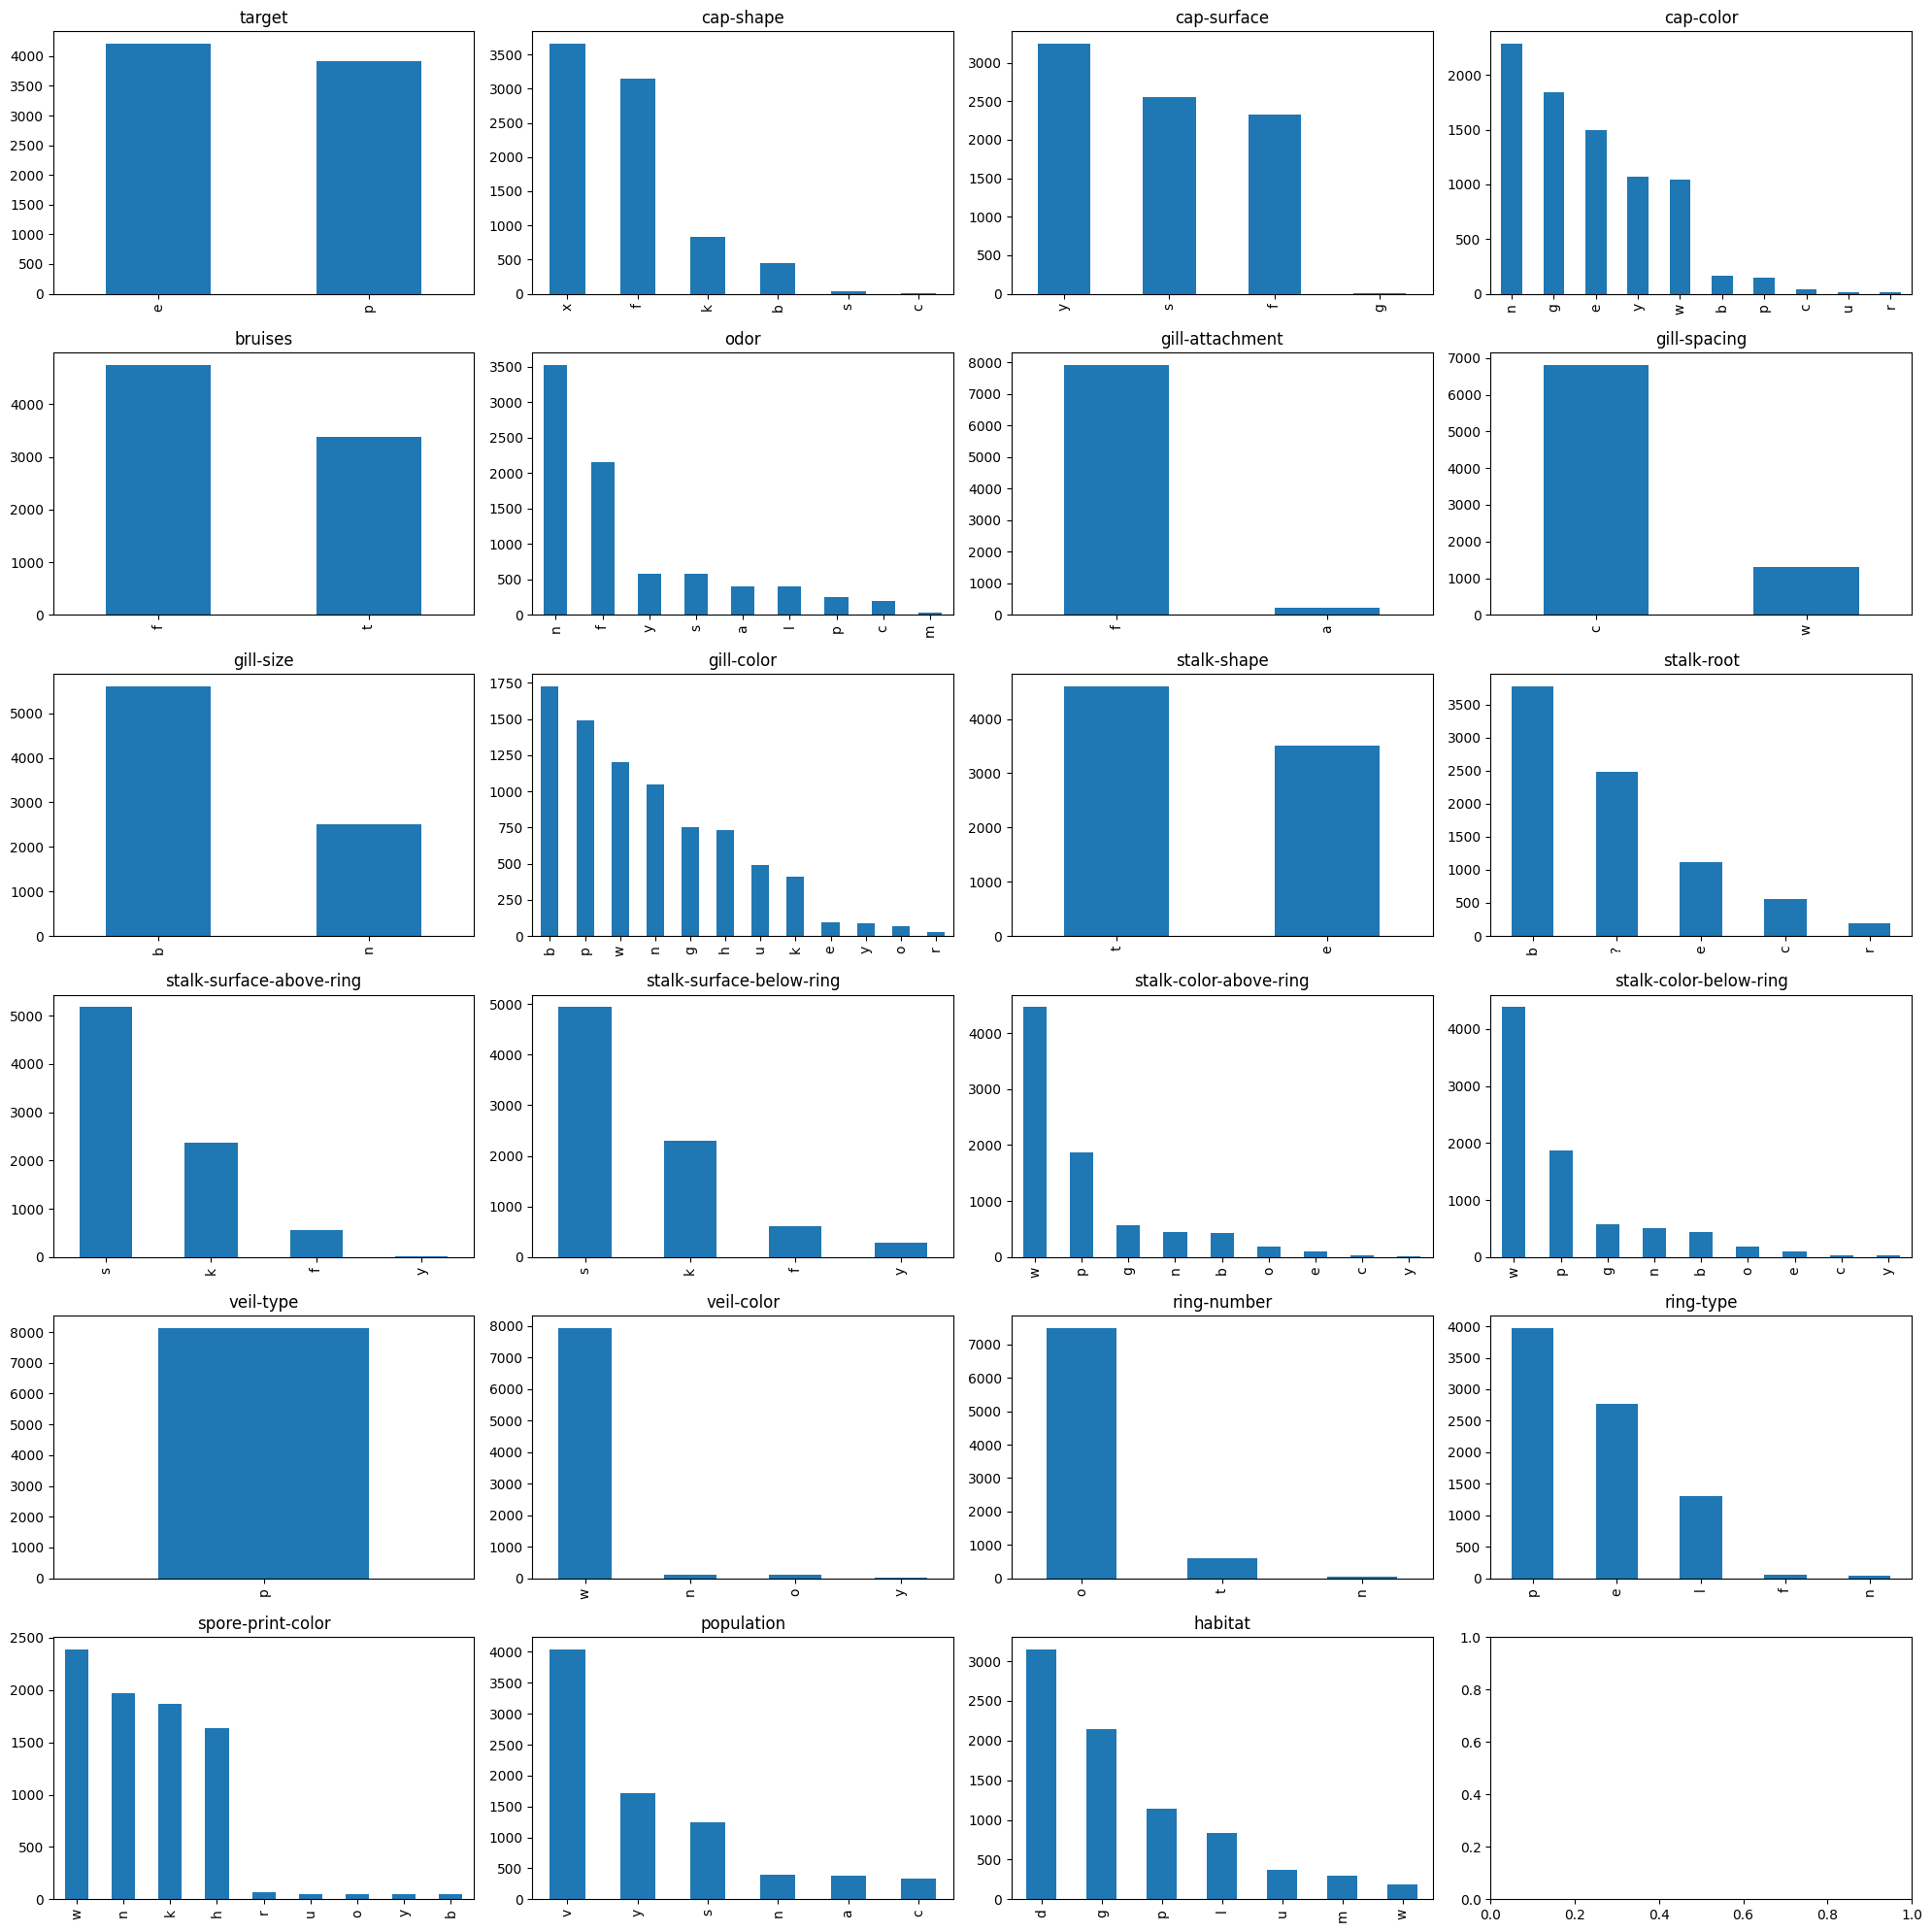

In [6]:
# Feature distributions

fig, axes = plt.subplots(nrows = 6, ncols = 4, figsize = (20, 20))
axes = axes.flatten()
for i, col in enumerate(df.columns):
    df[col].value_counts().plot(kind = 'bar', ax = axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel('')
plt.tight_layout()
plt.show()


some features are pretty imbalanced so we might want to consider removing them

In [7]:
# chi-squared test
from scipy.stats import chi2_contingency

results = []
for col in df.drop(columns=['target']).columns:
    contingency_table = pd.crosstab(df[col], df['target'])
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    results.append({'feature': col, 'chi2': chi2, 'p-value': p})
chi2_df = pd.DataFrame(results).sort_values('chi2', ascending=False)
print(chi2_df)

                     feature         chi2        p-value
4                       odor  7659.726740   0.000000e+00
19         spore-print-color  4602.033170   0.000000e+00
8                 gill-color  3765.714086   0.000000e+00
18                 ring-type  2956.619278   0.000000e+00
11  stalk-surface-above-ring  2808.286287   0.000000e+00
12  stalk-surface-below-ring  2684.474076   0.000000e+00
7                  gill-size  2366.834257   0.000000e+00
13    stalk-color-above-ring  2237.898496   0.000000e+00
14    stalk-color-below-ring  2152.390891   0.000000e+00
3                    bruises  2041.415647   0.000000e+00
20                population  1929.740891   0.000000e+00
21                   habitat  1573.777261   0.000000e+00
10                stalk-root  1344.440527  7.702048e-290
6               gill-spacing   984.143333  5.022978e-216
0                  cap-shape   489.919954  1.196457e-103
2                  cap-color   387.597769   6.055815e-78
17               ring-number   

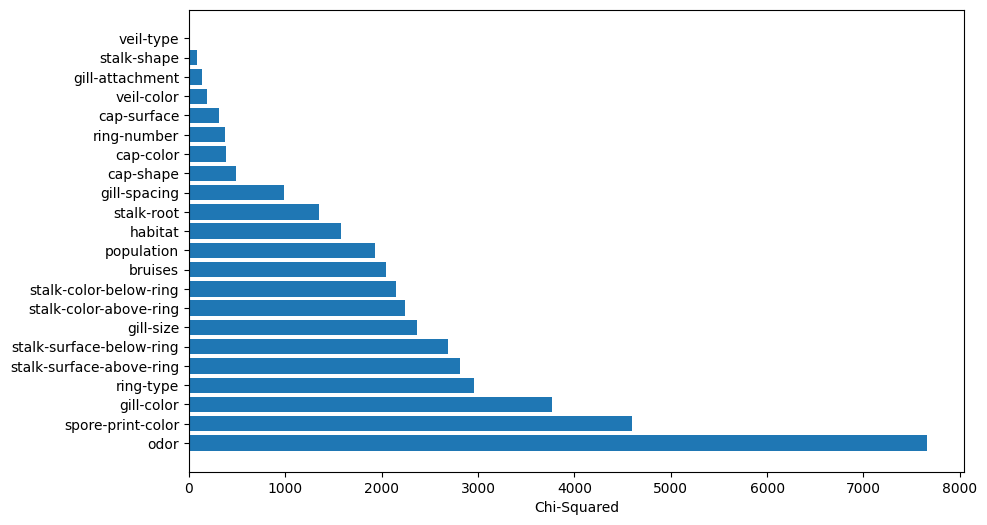

In [8]:
# visual for chi-squared
plt.figure(figsize=(10, 6))
plt.barh(chi2_df['feature'], chi2_df['chi2'])
plt.xlabel('Chi-Squared')
plt.savefig('../results/chi_squared.png')
plt.show()

the chi-squared results are sorted, so we can see which features have a stronger association with the target var. veil-type has a chi2 of zero, so we should drop. the rest of the vars are statistically significant but their p-values are still pretty low comparatively. should we keep them all or drop a few? not sure!

In [9]:
# cleaned data

df_model = df.copy()
df_model['stalk-root'] = df_model['stalk-root'].replace('?', 'unknown')
df_model = df_model.drop(columns=['veil-type'])
df_model.to_csv('../data/cleaned_mushrooms.csv', index=False)